# Projet de Classification de la Langue des Signes Arabe

**Binome :** RAMMAL Ziad _ YESGUER Melissa

**UE :** Bureau d'etude Apprentissage Automatique

---
## 1. Objectif du Projet et Description des Données

### 1.1 Objectif

L'objectif principal de ce projet est de concevoir, entraîner et évaluer un système basé sur l'apprentissage profond (Deep Learning) capable de reconnaître et de classifier les lettres de l'alphabet de la langue des signes arabe en temps réel et/ou à partir d'images.

Ce système vise à servir de base pour une application de traduction en temps réel, ce qui faciliterait la communication entre les personnes sourdes et malentendantes et le reste de la société dans le monde arabophone. En permettant la traduction automatique de gestes manuels en texte, nous espérons contribuer à briser les barrières de communication et à promouvoir une meilleure inclusion sociale.


### 1.2 Jeu de Données

Le jeu de données utilisé dans ce projet est **ARSL-No-BackGround-V2** (Arabic Sign Language). Il est spécifiquement conçu pour la reconnaissance des lettres de l'alphabet arabe en langue des signes.

- **Nombre de classes :** 31 .
- **Nombre total d'images :** 6985 images.
- **Type de données :** Images en couleur (RGBA).

Les images sont "segmentées", c'est-à-dire que l'arrière-plan a été supprimé. Cette caractéristique est cruciale car elle réduit le bruit visuel et permet au modèle de se concentrer uniquement sur la forme et la position de la main, ce qui améliore la précision de la classification.

### 1.3 Librairies Utilisées et Configuration

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

import keras
from keras import layers
from keras.models import Model

import splitfolders

### 1.4 Prétraitement des Données

Pour préparer les données à l'entraînement du réseau de neurones, nous avons appliqué les prétraitement suivants :

1.  **Division des données (Split) :** Le dataset a été divisé en trois sous-ensembles en utilisant la bibliothèque `splitfolders`  :
    - **Entraînement (80%)** : Utilisé pour apprendre les poids du réseau.
    - **Validation (10%)** : Utilisé pendant l'entraînement pour ajuster les hyperparamètres et pour détecter le sur-apprentissage (overfitting).
    - **Test (10%)** : Cet ensemble sert à l'évaluation finale des performances du modèle sur des données qu'il n'a jamais vues.

2.  **Chargement et Normalisation :** Nous avons utilisé `ImageDataGenerator` (TensorFlow/Keras) pour charger les images depuis les dossiers. Ensuite nous avons appliquer une **normalisation**, où chaque pixel a été divisé par 255 (`rescale=1./255`). Cela transforme les valeurs des pixels de l'intervalle `[0, 255]` vers `[0, 1]`, ce qui est essentiel pour la convergence stable des algorithmes de gradient.

3.  **Redimensionnement :** Le réseau pré-entraîné **VGG16** que nous avons utilisé par la suite exige des images d'entrée de taille fixe. Toutes les images ont donc été redimensionnées à **224x224 pixels**.

In [2]:
# SPLIT
data_dir = r'C:\Users\ziadr\Desktop\Projet ML\G1_SIA2_Langage_de_signes\ARSL-No-BackGround-V2' #Chemin de notre base de donnees
output_dir = r'C:\Users\ziadr\Desktop\Projet ML\G1_SIA2_Langage_de_signes\split' #Chemin de dossier contenant la base de donnees partagees

splitfolders.ratio(data_dir, output_dir, seed=1337, ratio=(0.8, 0.1,0.1))

# Chemins des dossiers train, val et test
train_dir = r'C:\Users\ziadr\Desktop\Projet ML\G1_SIA2_Langage_de_signes\split\train'
test_dir = r'C:\Users\ziadr\Desktop\Projet ML\G1_SIA2_Langage_de_signes\split\test'
val_dir = r'C:\Users\ziadr\Desktop\Projet ML\G1_SIA2_Langage_de_signes\split\val'

# Normalisation des images de chaque dossier
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

Copying files: 6985 files [00:08, 816.07 files/s]


Found 5575 images belonging to 31 classes.
Found 726 images belonging to 31 classes.
Found 684 images belonging to 31 classes.


A la sortie, on obtient trois dossier sous dossier :
*   `train` : 5575 images sur 31 classes.
*   `val` : 726 images sur 31 classes.
*   `test` : 684 images sur 31 classes.



---
## 2. Évolution du Projet et Choix du Modèle

### 2.1 Modèle Initial :

Nous avons d'abord construit un réseau convolutif (CNN) simple.
Son architecture est la suivante :

- **Blocs Convolutionnels :** Trois blocs successifs. Chaque bloc est composé de :
    - Une couche de convolution (Conv2D) avec des filtres de taille 3x3 et un nombre de filtres croissant (50, 100, 200) avec la fonction d'activation `ReLU` .
    - Une **BatchNormalization** : Cette couche normalise les activations de la couche précédente. Elle accélère l'apprentissage et le rend plus stable.
    - Un **MaxPooling** (2x2) : Réduit la dimension spatiale des cartes de caractéristiques, rendant le modèle plus robuste aux petites translations dans l'image.

- **Partie Dense (Fully Connected) :**
    - Après avoir "aplati" (Flatten) les cartes de caractéristiques de la dernière couche de pooling, nous avons ajouté trois couches denses (500, 100 et 50 neurones).
    - **Dropout (30%)** : Introduit avant les couches denses, ce mécanisme désactive aléatoirement 30% des neurones pendant l'entraînement. C'est une technique de régularisation très efficace pour lutter contre le sur-apprentissage.

- **Couche de Sortie :** Une couche dense avec 31 neurones et une fonction d'activation **Softmax**. Cette fonction convertit les scores bruts en probabilités (somme égale à 1), nous donnant la probabilité que l'image appartienne à chacune des 31 classes.

In [3]:
# CODE DE NOTRE MODELE

NB_CLASSES = 31  # number of outputs = number of digits

#build the model
model = models.Sequential()

model.add(layers.Convolution2D(50, (3, 3), padding= 'same',input_shape=(224, 224, 3), activation='relu'))
#  Batch Normalization
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
# 2eme couche CONV + POOL
model.add(layers.Convolution2D(100, (3, 3), padding= 'same', activation='relu'))
#  Batch Normalization
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
# 3eme couche CONV + POOL
model.add(layers.Convolution2D(200, (3, 3), padding= 'same', activation='relu'))
#  Batch Normalization
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
# Flatten
model.add(layers.Flatten())

# couche dense (totalement connectée) avec 500 neurones
model.add(layers.Dense(500, activation="relu"))

# 50% de dropout
model.add(layers.Dropout(0.3))
model.add(layers.Dense(100, activation="relu"))
model.add(layers.Dense(50, activation="relu"))
# softmax dense classifier
model.add(layers.Dense(NB_CLASSES, activation="softmax"))


In [4]:
# summary of the model
model.summary()

# compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['accuracy']) # SGD


from keras.callbacks import EarlyStopping
#training the model
EPOCHS = 20
VERBOSE = 1
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

history = model.fit(train_gen, epochs=EPOCHS, verbose=VERBOSE, validation_data=val_gen, callbacks=[es])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 50)      1400      
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 50)     200       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 50)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 100)     45100     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 100)    400       
 hNormalization)                                                 
                                                        


**Analyse des résultats :** Après l'entraînement, nous avons observé un écart significatif entre l'accuracy sur l'ensemble d'entraînement (>90%) et sur l'ensemble de validation (environ 50%). Ce phénomène, appelé **sur-apprentissage (overfitting)**, indique que notre modèle a appris par cœur les données d'entraînement sans parvenir à généraliser sur des données nouvelles. Les visualisations des courbes d'apprentissage confirment cette divergence nette.


23/23 [==============================] - 1s 42ms/step - loss: 2.4769 - accuracy: 0.5110
Test accuracy: 0.5110192894935608
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


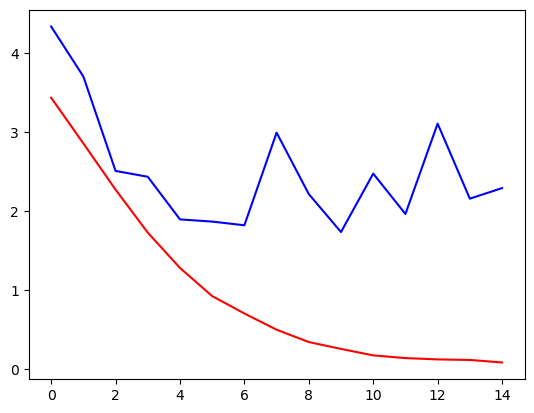

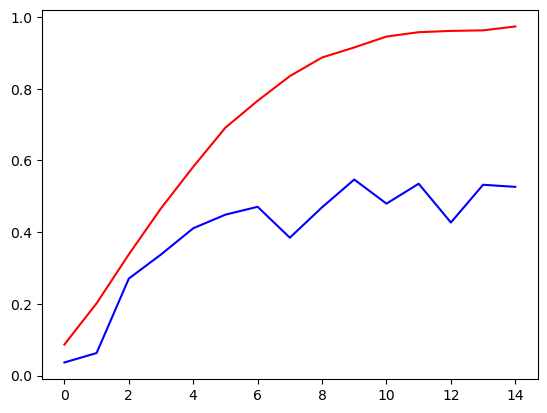

In [5]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_gen)
print('Test accuracy:', test_acc)

print(history.history.keys())
plt.figure()
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')

plt.figure()
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')

### 2.2 Amélioration : Transfer Learning et Fine-Tuning
Pour améliorer la capacité de généralisation de notre modèle, nous avons mis en œuvre deux stratégies principales.

#### 1. Transfer Learning avec VGG16

Le *Transfer Learning* consiste à réutiliser un modèle pré-entraîné sur un très grand dataset (généralement **ImageNet**) comme point de départ pour une nouvelle tâche. Nous avons choisi **VGG16**, un réseau reconnu pour sa performance en classification d'images.

- **Architecture de VGG16 :** Ce réseau est composé de plusieurs blocs de couches convolutives suivis de couches de *pooling*. Les premières couches apprennent à détecter des motifs simples (bords, textures), tandis que les couches plus profondes apprennent des motifs plus complexes (formes, objets).

- **Stratégie de Fine-Tuning :**
    - Nous avons gelé/bloqué les poids des 10 premières couches de VGG16 (les couches qui capturent les motifs très génériques), les rendant non entraînables.
    - Les couches plus profondes (à partir du bloc 3) ont été laissées **entraînables**. Cela permet au modèle d'ajuster ses représentations pour les adapter à notre tâche spécifique.
    - Nous avons ensuite ajouté notre propre classificateur (couches denses) à la sortie de VGG16.

#### 2. Data Augmentation

L'*augmentation de données* est une technique qui crée artificiellement de nouvelles images d'entraînement en appliquant plusieurs transformations aux images originales. Cela aide à augmenter la taille du dataset et l'enrichir, forçant le modèle à apprendre des caractéristiques plus robustes. Nous avons utilisé `ImageDataGenerator` avec les paramètres suivants :

- **Décalages (Width/Height Shift) :** Translation horizontale et verticale.
- **Zoom :** Zoom aléatoire.
- **Luminosité (Brightness Range) :** Légères variations de la luminosité.
- **Retournement Horizontal :** Symétrie horizontale.

In [6]:
#CODE DE VGG16
num_classes = 31

base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

for layer in base_model.layers[:10]:
    layer.trainable = False

# Pour voir quelles sont les couches entraînables
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

# Pour que les paramètres des couches convolutives ne soient pas modifies.
base_model.summary()
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(200, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
    ])


0 input_1 False
1 block1_conv1 False
2 block1_conv2 False
3 block1_pool False
4 block2_conv1 False
5 block2_conv2 False
6 block2_pool False
7 block3_conv1 False
8 block3_conv2 False
9 block3_conv3 False
10 block3_pool True
11 block4_conv1 True
12 block4_conv2 True
13 block4_conv3 True
14 block4_pool True
15 block5_conv1 True
16 block5_conv2 True
17 block5_conv3 True
18 block5_pool True
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
  

In [7]:
#Code de data augmentation

train_datagen = ImageDataGenerator(rescale = 1./ 255,
                              width_shift_range = 0.05,
                              height_shift_range = 0.05,
                              horizontal_flip = True,
                              vertical_flip = False,
                              #rotation_range = 45,
                              brightness_range = [0.9, 1.1],
                              zoom_range = [0.9, 1.1])


train_gen = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)



Found 5575 images belonging to 31 classes.


---
## 3. Apprentissage du Modèle Final

In [8]:
import scipy.ndimage as ndimage
# ou si cela ne suffit pas
from scipy import ndimage

# compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['accuracy']) # SGD

#training the model
EPOCHS = 64

VERBOSE = 1

from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

history = model.fit(train_gen, epochs=EPOCHS,
		  verbose=VERBOSE, validation_data=val_gen, callbacks=[es])



Epoch 1/64
175/175 [==============================] - 41s 232ms/step - loss: 2.4903 - accuracy: 0.2836 - val_loss: 1.0153 - val_accuracy: 0.6550
Epoch 2/64
175/175 [==============================] - 40s 229ms/step - loss: 0.7151 - accuracy: 0.7652 - val_loss: 0.3304 - val_accuracy: 0.8962
Epoch 3/64
175/175 [==============================] - 41s 231ms/step - loss: 0.3415 - accuracy: 0.8918 - val_loss: 0.2301 - val_accuracy: 0.9313
Epoch 4/64
175/175 [==============================] - 39s 224ms/step - loss: 0.2124 - accuracy: 0.9340 - val_loss: 0.2296 - val_accuracy: 0.9211
Epoch 5/64
175/175 [==============================] - 40s 229ms/step - loss: 0.1562 - accuracy: 0.9505 - val_loss: 0.1749 - val_accuracy: 0.9503
Epoch 6/64
175/175 [==============================] - 40s 227ms/step - loss: 0.0933 - accuracy: 0.9713 - val_loss: 0.1592 - val_accuracy: 0.9444
Epoch 7/64
175/175 [==============================] - 41s 233ms/step - loss: 0.1061 - accuracy: 0.9743 - val_loss: 0.2145 - val_ac

### 3.1 Courbes d'Apprentissage

La combinaison de ces deux techniques a produit un modèle extrêmement performant, atteignant une **précision superieur à 97% sur l'ensemble de test**. Les courbes d'apprentissage montrent désormais une excellente convergence entre l'entraînement et la validation, signe d'une bonne généralisation.

23/23 [==============================] - 2s 82ms/step - loss: 0.1417 - accuracy: 0.9614
Test accuracy: 0.9614325165748596
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


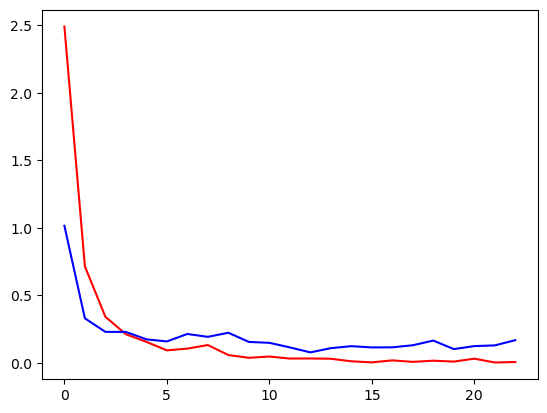

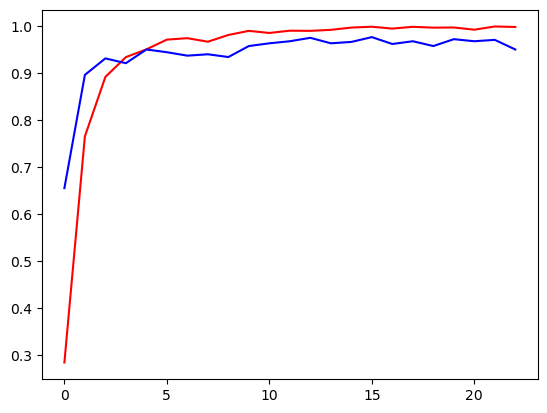

In [9]:
# code de visualisation

test_loss, test_acc = model.evaluate(test_gen)
print('Test accuracy:', test_acc)


print(history.history.keys())
plt.figure()
plt.plot(history.history['loss'],'r',label='loss')
plt.plot(history.history['val_loss'],'b',label='Val_loss')

plt.figure()
plt.plot(history.history['accuracy'],'r',label='accuracy')
plt.plot(history.history['val_accuracy'],'b',label='Val_accuracy')


### 3.2 Sauvegarde du Modèle pour l'API

In [10]:
# Sauvegarde de modèle
model_json = model.to_json()
with open('model.json','w') as json_file:
    json_file.write(model_json)
    model.save_weights('model.h5')

---
## 4. Analyse des Résultats et Évaluation

In [11]:
# Chargement de modèle

from tensorflow.keras.models import model_from_json
model_architecture = 'model.json'
model_weights = 'model.h5'
model = model_from_json(open(model_architecture).read())
model.load_weights(model_weights)


### 4.1 Matrice de Confusion et Métriques

L'analyse de la matrice de confusion révèle que les confusions principales surviennent entre des lettres visuellement similaires (gestes impliquant des configurations de doigts proches). Cela suggère qu'une partie de la difficulté réside dans la similarité inhérente de certaines classes, un défi même pour un humain.

Found 726 images belonging to 31 classes.
23/23 [==============================] - 1s 50ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.00      0.00      0.00        27
           2       0.00      0.00      0.00        28
           3       0.07      0.07      0.07        29
           4       0.00      0.00      0.00        23
           5       0.17      0.15      0.16        20
           6       0.00      0.00      0.00        24
           7       0.05      0.05      0.05        22
           8       0.04      0.04      0.04        23
           9       0.00      0.00      0.00        25
          10       0.06      0.05      0.06        19
          11       0.07      0.07      0.07        27
          12       0.00      0.00      0.00        22
          13       0.00      0.00      0.00        26
          14       0.09      0.08      0.09        24
          15       0.00      0.00      

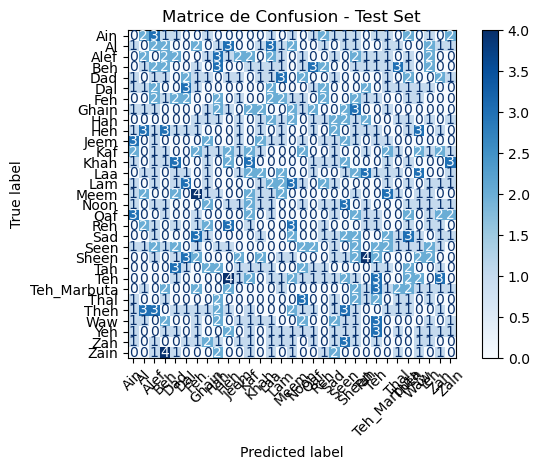

In [12]:
# Metrique et matrice de confusion pour l'ensemble de test

test_dir = r'C:\Users\ziadr\Desktop\Projet ML\G1_SIA2_Langage_de_signes\split\test'

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, 1)
labels = test_gen.classes

print(classification_report(labels, y_pred))

# Calcul de la matrice
cm = confusion_matrix(labels, y_pred)

# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matrice de Confusion - Test Set')
plt.tight_layout()
plt.show()


### 4.2 Visualisation des filtres du Modèle

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 25088)             0         
                                                                 
 dense_4 (Dense)             (None, 200)               5017800   
                                                                 
 dense_5 (Dense)             (None, 100)               20100     
                                                                 
 dense_6 (Dense)             (None, 31)                3131      
                                                                 
Total params: 19,755,719
Trainable params: 18,020,231
Non-trainable params: 1,735,488
_________________________________________________________________
Model: "vgg16"
___________________

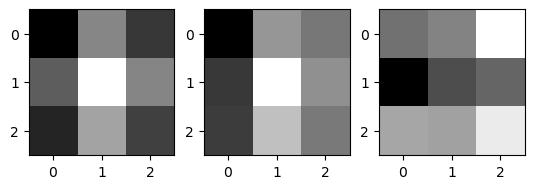

In [13]:
# Visualisation des filtres

model.summary()
base_model = model.layers[0]
base_model.summary()

# Récupérer les filtres et les poids de la 1ère couche
filters, biases, *is_anything_else_being_returned = base_model.layers[1].get_weights()

# Normalisation des filtres sur [0 , 1]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Visualiser les 3 sous-filtres (canaux R, V et B) de deuxième filtre de cette couche
f=filters[:,:,:,1]
plt.figure()
plt.subplot(1,3,1)
plt.imshow(f[:, :, 0], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(f[:, :, 1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(f[:, :, 2], cmap='gray')

### 4.2.1 Visualisation de la sortie des filtres

 L'observation des sorties des premières couches convolutives confirme que le modèle apprend bien à détecter des primitives visuelles de bas niveau (contours, textures, orientations). Ces motifs simples sont ensuite combinés par les couches plus profondes pour former des représentations plus abstraites et sémantiques (forme de la main, position des doigts).

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
Total params: 1,792
Trainable params: 0
Non-trainable params: 1,792
_________________________________________________________________
1/1 [==============================] - 0s 41ms/step


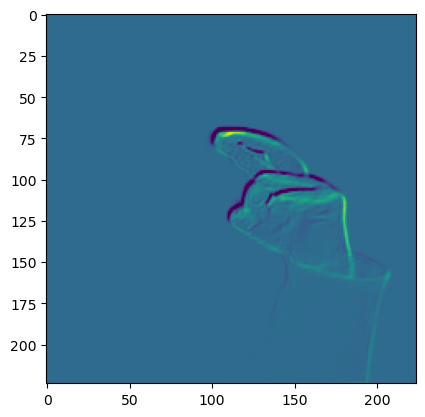

In [14]:
from PIL import Image
import cv2

# Image test pour visualiser la sortie du filtre selectionné
fichier = "C:/Users/ziadr/Desktop/Projet ML/G1_SIA2_Langage_de_signes/split/test/Zain/Zain_21.jpg"

image = Image.open(fichier)
image = np.asarray(image)
image=image.astype('float32')
image = cv2.cvtColor(image,cv2.COLOR_RGBA2RGB)
image=cv2.resize(image,(224,224))
image /= 255
image = image.reshape([-1,224,224,3])

inter_model = Model(inputs=base_model.inputs, outputs=base_model.layers[1].output)
inter_model.summary()
feature_maps = inter_model.predict(image)
plt.figure()
plt.imshow(feature_maps[0,:,:,0])


### 4.3 Analyse des Prédictions (Correctes vs Incorrectes)

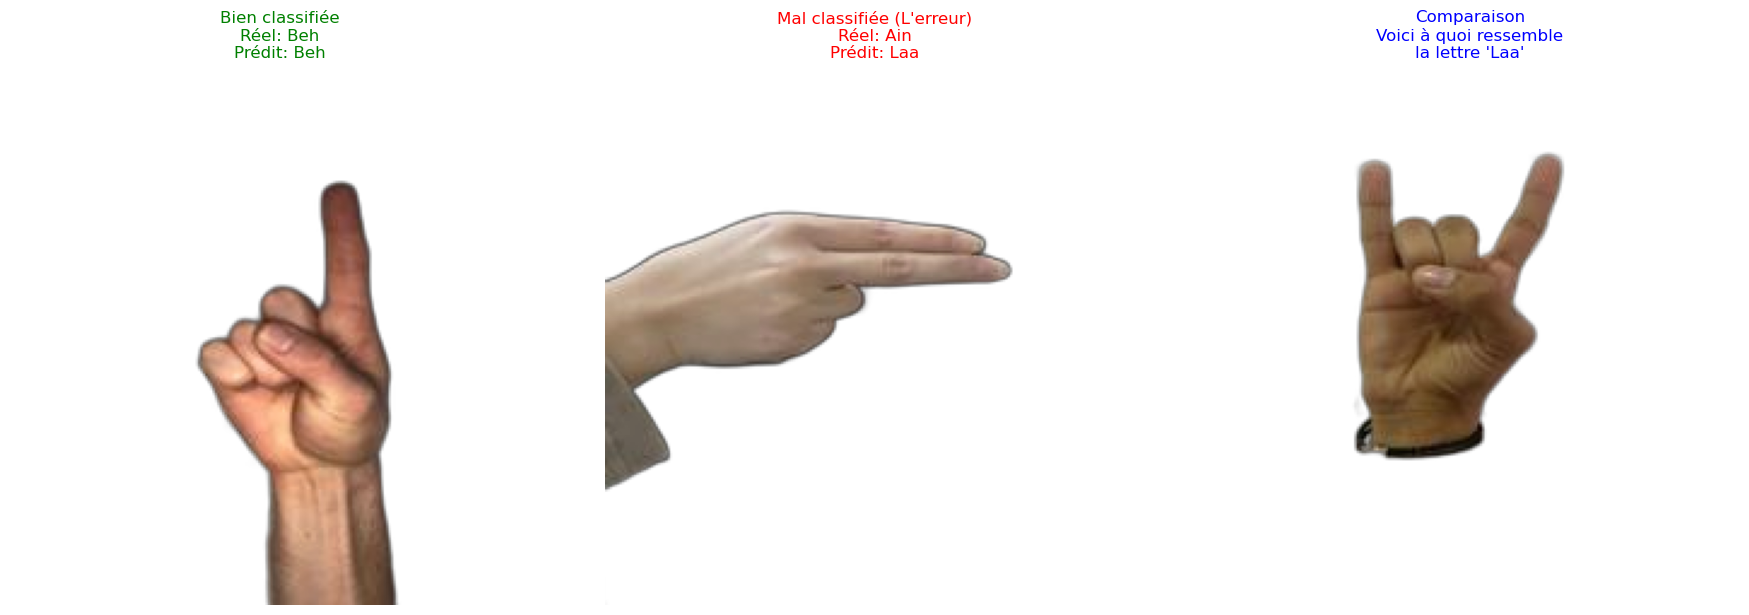

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Préparations des données
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Trouver les indices
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]


plt.figure(figsize=(18, 6))

# IMAGE BIEN CLASSÉE
if len(correct_indices) > 0:
    idx_ok = correct_indices[0]
    plt.subplot(1, 3, 1)
    img_ok = plt.imread(test_gen.filepaths[idx_ok])
    plt.imshow(img_ok)
    plt.title(f"Bien classifiée\nRéel: {class_labels[y_true[idx_ok]]}\nPrédit: {class_labels[y_pred[idx_ok]]}", color='green')
    plt.axis('off')

# IMAGE MAL CLASSÉE
if len(incorrect_indices) > 0:
    idx_error = incorrect_indices[0] # On prend la première erreur
    vrai_label_index = y_true[idx_error]
    label_errone = y_pred[idx_error]

    # Affichage de l'erreur
    plt.subplot(1, 3, 2)
    img_error = plt.imread(test_gen.filepaths[idx_error])
    plt.imshow(img_error)
    plt.title(f"Mal classifiée (L'erreur)\nRéel: {class_labels[vrai_label_index]}\nPrédit: {class_labels[label_errone]}", color='red')
    plt.axis('off')

    # LE BON SIGNE POUR COMPARAISON
    # On cherche dans le dataset une image qui porte l'étiquette de la mauvaise prédiction
    # pour voir à quoi ressemble la lettre que le modèle a cru voir.
    plt.subplot(1, 3, 3)
    idx_comparison = np.where(y_true == label_errone)[0][0]
    img_comparison = plt.imread(test_gen.filepaths[idx_comparison])

    plt.imshow(img_comparison)
    plt.title(f"Comparaison\nVoici à quoi ressemble\nla lettre '{class_labels[label_errone]}'", color='blue')
    plt.axis('off')

plt.tight_layout()
plt.show()

---
## 5. Déploiement : Création d'une Application de Traduction

Afin de démontrer l'utilité pratique de notre modèle, nous l'avons intégré dans une application web interactive. Cette application permet à un utilisateur de réaliser des signes devant sa webcam ou de télécharger une image pour obtenir une traduction en temps réel.


**Outils utilisées :**
- **Streamlit :** Framework Python permettant de créer des applications web pour le Machine Learning rapidement et facilement.
- **MediaPipe :** Bibliothèque développée par Google pour le traitement multimédia. Ici, elle est utilisée pour la détection de la main. Elle localise la main dans l'image, la recadre, et ne garde que la région d'intérêt. Cela simule le prétraitement "sans arrière-plan" des données d'entraînement.

**Fonctionnalités de l'application :**
- **Détection de la main :** Si l'image contient une main, l'application utilise MediaPipe pour la détecter et la recadrer.
- **Prédiction en temps réel :** L'image recadrée est passée à notre modèle VGG16, qui prédit la lettre signée.
- **Construction de phrases :** L'utilisateur peut construire une phrase en arabe de manière interactive.
    - Un bouton permet d'**ajouter la lettre reconnue** à la phrase.
    - Des boutons sont disponibles pour **insérer un espace** ou **tout effacer**.
- **Persistance de l'état :** La phrase en cours de construction est stockée dans `st.session_state`. Cela garantit que la phrase n'est pas perdue lorsqu'une nouvelle image est téléchargée ou qu'un bouton est pressé, offrant ainsi une expérience utilisateur fluide.


Cette démonstration prouve la viabilité d'un tel système pour une future application grand public d'aide à la communication pour les personnes sourdes et malentendantes du monde arabophone.

In [ ]:
from __future__ import annotations
import streamlit as st
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import mediapipe as mp
from tensorflow.keras.models import model_from_json

# INITIALISATION ET MÉMOIRE

# On utilise st.session_state pour que les lettres ne s'effacent pas quand la page se rafraîchit
if 'phrase' not in st.session_state:
    st.session_state.phrase = ""

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

nom_classe = [
    "Ain", "Al", "Alef", "Beh", "Dad", "Dal", "Feh", "Ghain", "Hah", "Heh",
    "Jeem", "Kaf", "Khah", "Laa", "Lam", "Meem", "Noon", "Qaf", "Reh", "Sad",
    "Seen", "Sheen", "Tah", "Teh", "Teh_Marbuta", "Thal", "Theh", "Waw", "Yeh",
    "Zah", "Zain"
]
# Mapping entre le nom de la classe et le caractère arabe
mapping_arabe = {
    "Ain": "ع", "Al": "ال", "Alef": "أ", "Beh": "ب", "Dad": "ض",
    "Dal": "د", "Feh": "ف", "Ghain": "غ", "Hah": "ح", "Heh": "ه",
    "Jeem": "ج", "Kaf": "ك", "Khah": "خ", "Laa": "لا", "Lam": "ل",
    "Meem": "م", "Noon": "ن", "Qaf": "ق", "Reh": "ر", "Sad": "ص",
    "Seen": "س", "Sheen": "ش", "Tah": "ط", "Teh": "ت", "Teh_Marbuta": "ة",
    "Thal": "ذ", "Theh": "ث", "Waw": "و", "Yeh": "ي", "Zah": "ظ",
    "Zain": "ز"
}

@st.cache_data
# Chargement de modele
def load_trained_model():
    try:
        model = model_from_json(open('model.json').read())
        model.load_weights('model.h5')
        return model
    except Exception as e:
        st.error(f"Erreur modèle : {e}")
        return None

model = load_trained_model()

# Traitement

def get_hand_crop(image_pil):
    img = np.array(image_pil.convert('RGB'))
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    h, w, _ = img_bgr.shape
    results = hands.process(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            x_coords = [lm.x * w for lm in hand_landmarks.landmark]
            y_coords = [lm.y * h for lm in hand_landmarks.landmark]
            center_x, center_y = (min(x_coords) + max(x_coords)) / 2, (min(y_coords) + max(y_coords)) / 2
            box_size = max(max(x_coords) - min(x_coords), max(y_coords) - min(y_coords)) * 1.4

            x1, y1 = int(max(0, center_x - box_size/2)), int(max(0, center_y - box_size/2))
            x2, y2 = int(min(w, center_x + box_size/2)), int(min(h, center_y + box_size/2))

            roi = img_bgr[y1:y2, x1:x2]
            if roi.size == 0: return None, None, False

            roi_resized = cv2.resize(roi, (224, 224))
            roi_rgb = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2RGB)
            img_tensor = roi_rgb.astype('float32') / 255.0
            img_tensor = np.expand_dims(img_tensor, axis=0)

            return img_tensor, roi_rgb, True
    return None, None, False

# Interface

st.title("Classification des lettres de signe (version arabe) : Mode Traduction")

# Zone de texte pour afficher la phrase construite
st.markdown(
    f"""
    <div style="text-align: right; direction: rtl; font-size: 40px; background-color: #000000; padding: 20px; border-radius: 10px;">
        {st.session_state.phrase}
    </div>
    """,
    unsafe_allow_html=True
)

source = st.radio("Source :", ("Webcam", "Upload"))
img_file = st.camera_input("Faites votre signe") if source == "Webcam" else st.file_uploader("Image", type=["jpg", "png", "jpeg"])

if img_file:
    image_pil = Image.open(img_file)
    input_ia, img_display, detected = get_hand_crop(image_pil)

    if detected:
        col_img, col_act = st.columns([1, 1])

        with col_img:
            st.image(img_display, caption="Signe détecté", use_column_width=True)

        with col_act:
            # Prédiction
            preds = model.predict(input_ia)[0]
            top_idx = np.argmax(preds)
            lettre_detectee = nom_classe[top_idx]
            confiance = preds[top_idx] * 100

            st.subheader(f"Lettre : :blue[{lettre_detectee}]")
            st.write(f"Confiance : {confiance:.1f}%")

            # BOUTONS DE TRADUCTION
            st.write("---")
            # On récupère le vrai caractère arabe
            caractere_arabe = mapping_arabe.get(lettre_detectee, lettre_detectee)

            if st.button(f"✅ Ajouter '{caractere_arabe}' ({lettre_detectee})"):
                # On ajoute le caractère arabe à la phrase
                st.session_state.phrase += caractere_arabe
                st.experimental_rerun()

            col_btn1, col_btn2 = st.columns(2)
            with col_btn1:
                if st.button("⌨️ Espace"):
                    st.session_state.phrase += " "
                    st.experimental_rerun()
            with col_btn2:
                if st.button("🗑️ Effacer"):
                    st.session_state.phrase = ""
                    st.experimental_rerun()
    else:
        st.warning("Main non détectée.")

---
## 6. Conclusion

L'objectif de ce projet était de développer un système de reconnaissance automatique des lettres de la langue des signes arabe à partir d'images, en s'appuyant sur des techniques d'apprentissage profond (Deep Learning).  

Nous avons démontré l'efficacité du Transfer Learning (VGG16) combiné au Fine-Tuning et à la Data Augmentation pour la classification des lettres de la langue des signes arabe, et ce, même avec un volume de données modéré.  

Le modèle final atteint une précision de 97 % sur l'ensemble de test, ce qui constitue une performance très satisfaisante pour ce type de tâche.

De plus, l'intégration de ce modèle dans une application interactive développée avec Streamlit démontre son potentiel pratique et opérationnel.  

Ce travail constitue ainsi une base solide pour le développement futur d'outils d'aide à la communication destinés aux personnes sourdes et malentendantes de la communauté arabophone.